In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import os

os.listdir()

['.config', 'netflix_titles.csv', 'archive.zip', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Netflix Movies & TV Shows - Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset. The project analyzes the dataset, cleans missing values, creates visualizations, and extracts meaningful insights.

## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

In [ ]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 3: Dataset Information

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


## Step 4: Data Cleaning

In [ ]:
# Create a copy of the dataset
df_clean = df.copy()

# Remove duplicate records
df_clean.drop_duplicates(inplace=True)

# Fill missing values
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Not Rated')

# Remove rows where date_added is missing
df_clean.dropna(subset=['date_added'], inplace=True)

# Check remaining missing values
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


## Question 1: How many Movies and TV Shows are available on Netflix?

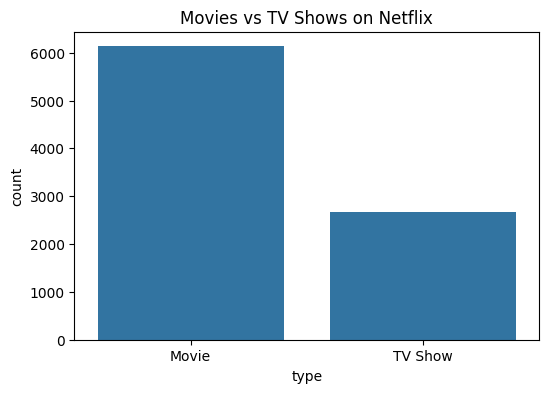

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df_clean)
plt.title('Movies vs TV Shows on Netflix')
plt.show()

## Question 2: Which are the Top 10 Countries producing Netflix content?

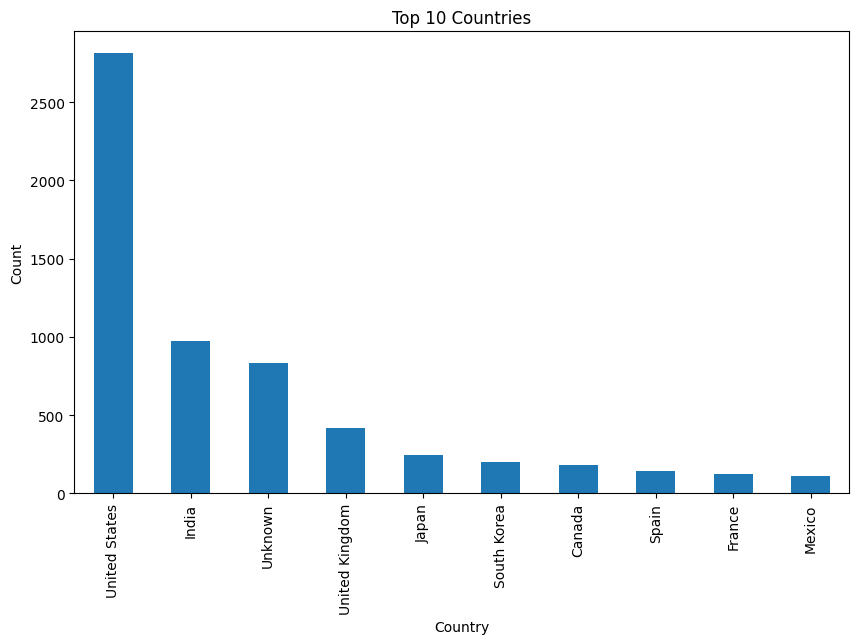

In [ ]:
plt.figure(figsize=(10,6))

df_clean['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

## Question 3: Content released over the years

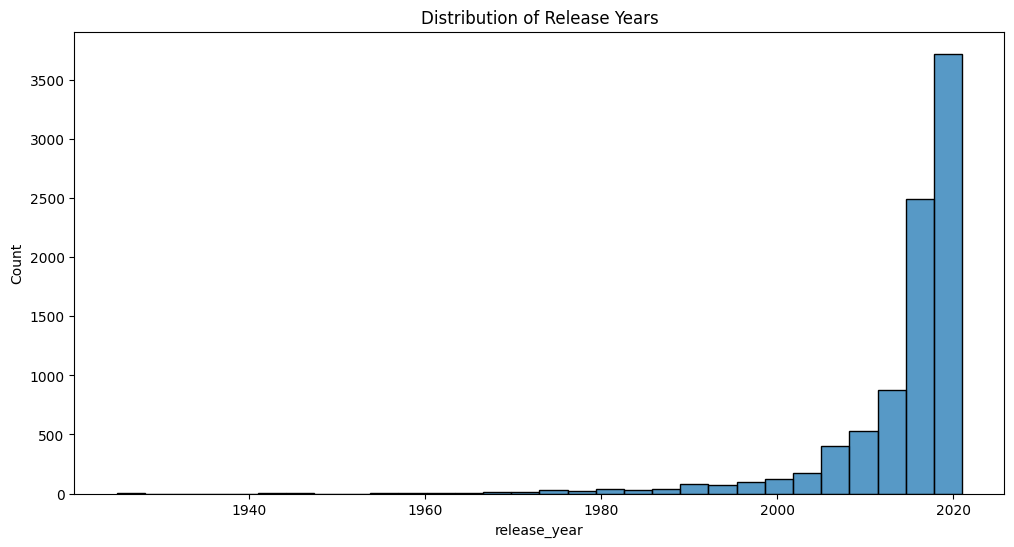

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(df_clean['release_year'], bins=30)

plt.title("Distribution of Release Years")

plt.show()

## Question 4: What are the most common content ratings on Netflix?

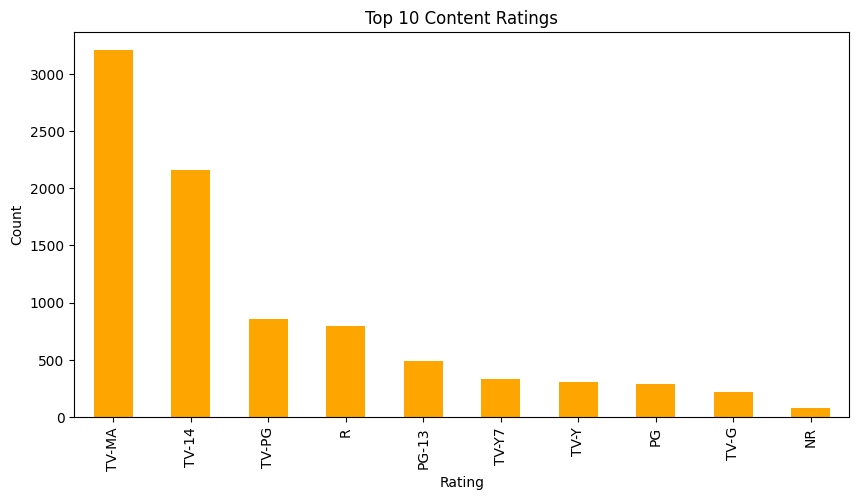

In [ ]:
plt.figure(figsize=(10,5))

df_clean['rating'].value_counts().head(10).plot(kind='bar', color='orange')

plt.title("Top 10 Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

## Question 5: What are the Top 10 Genres available on Netflix?

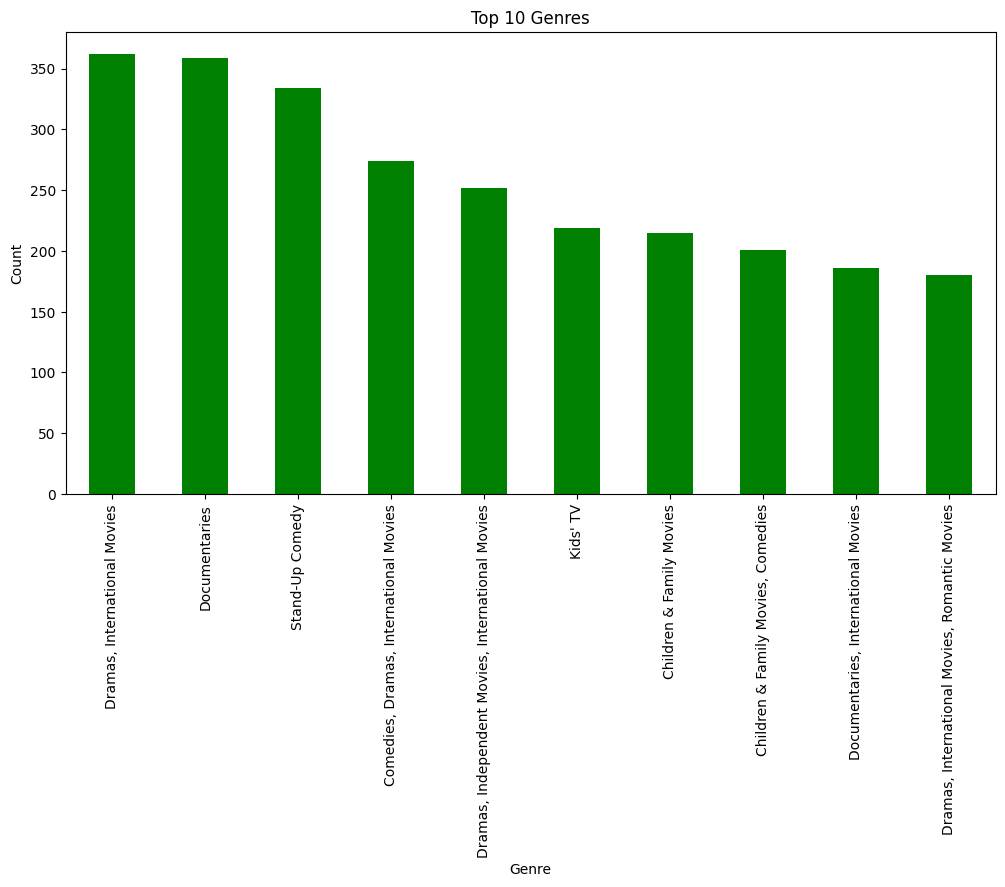

In [ ]:
plt.figure(figsize=(12,6))

df_clean['listed_in'].value_counts().head(10).plot(kind='bar', color='green')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

## Question 6: Percentage of Movies and TV Shows

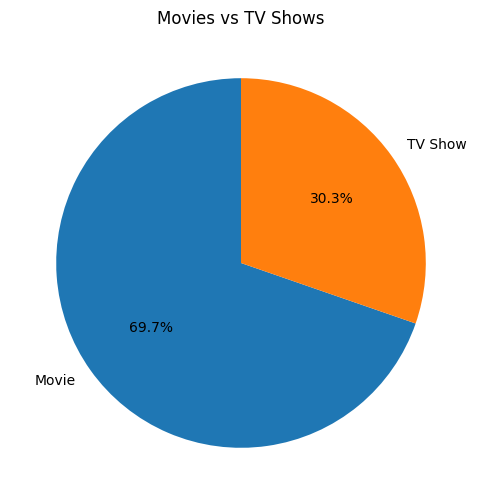

In [ ]:
plt.figure(figsize=(6,6))

df_clean['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Movies vs TV Shows")

plt.show()

# Business Insights

1. Netflix contains significantly more Movies than TV Shows.

2. The United States contributes the highest number of titles available on Netflix.

3. Most Netflix content has been released after 2015, showing rapid growth in recent years.

4. TV-MA and TV-14 are the most common content ratings.

5. International content has increased significantly, indicating Netflix's global expansion strategy.

# Conclusion

The exploratory data analysis of the Netflix Movies and TV Shows dataset revealed important trends regarding content distribution, production countries, release years, ratings, and genres. The analysis shows that Netflix focuses primarily on movies while continuously expanding its international content library. This project demonstrates the use of Python, Pandas, Matplotlib, and Seaborn for data cleaning, visualization, and business insight generation.